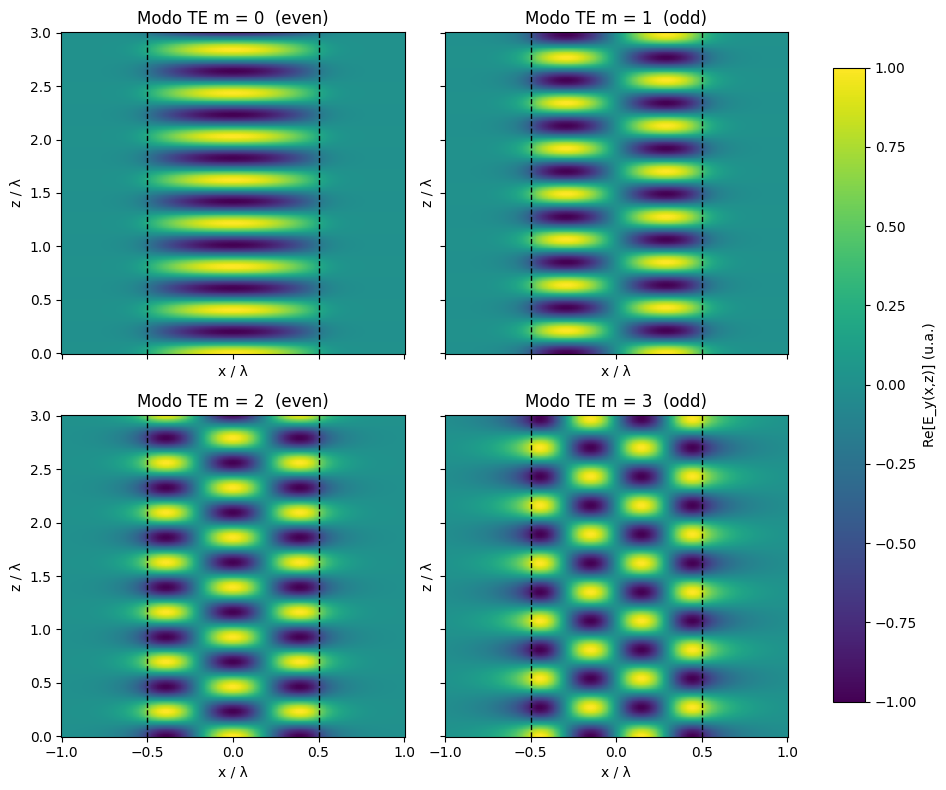

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# Parámetros del slab de Yeh
# ============================
n1 = 1.5          # índice de los claddings
n2 = 2.5          # índice del núcleo
lam = 1.0         # longitud de onda en el vacío (tomamos λ = 1 como unidad)
d = lam           # espesor del núcleo (d = λ)
k0 = 2*np.pi/lam  # número de onda en el vacío

# Valores de neff = β / k0 (Yeh, pág. 307) => "beta normalizada" en tu texto
beta_bar = np.array([2.463, 2.348, 2.148, 1.850])  # m = 0,1,2,3

# β físico de cada modo
beta = k0 * beta_bar

# Parámetros transversales h y q para cada modo (Yeh, Ec. 11.1-9 escrita en términos de neff)
h = k0 * np.sqrt(n2**2 - beta_bar**2)
q = k0 * np.sqrt(beta_bar**2 - n1**2)

# ============================
# Función con el perfil Em(x)
# ============================
def Em_profile(x, h_m, q_m, d, mode_type):
    """
    Devuelve Em(x) para un modo TE de slab:
    - mode_type = 'even'  -> modo par (cos dentro)
    - mode_type = 'odd'   -> modo impar (sin dentro)
    """
    x = np.array(x)
    Em = np.zeros_like(x, dtype=float)
    x_abs = np.abs(x)

    inside = x_abs < d/2        # |x| < d/2 núcleo
    outside = ~inside           # |x| > d/2 claddings

    if mode_type == "even":
        B = 1.0
        # Núcleo: cos(hx)
        Em[inside] = B * np.cos(h_m * x[inside])
        # Claddings: decaimiento exponencial simétrico
        Em[outside] = B * np.cos(h_m * d/2) * np.exp(-q_m * (x_abs[outside] - d/2))
    else:  # "odd"
        A = 1.0
        # Núcleo: sin(hx)
        Em[inside] = A * np.sin(h_m * x[inside])
        # Claddings: mismo signo que el núcleo en cada lado
        Em[outside] = (
            A * np.sign(x[outside]) *
            np.sin(h_m * d/2) *
            np.exp(-q_m * (x_abs[outside] - d/2))
        )

    # Normalizamos para que el máximo sea 1 (solo estética de la gráfica)
    Em /= np.max(np.abs(Em))
    return Em

# ============================
# Malla (x,z) para graficar
# ============================
# Tomamos un rango en x que incluya núcleo y claddings
x_min, x_max = -d, d
z_min, z_max = 0.0, 3*d   # unas cuantas longitudes de onda a lo largo de z

Nx, Nz = 400, 400
x = np.linspace(x_min, x_max, Nx)
z = np.linspace(z_min, z_max, Nz)
X, Z = np.meshgrid(x, z)

t0 = 0.0   # fijamos un tiempo (puede ser 0 sin problema)

# ============================
# Cálculo y gráficas de los 4 modos
# ============================
mode_types = ["even", "odd", "even", "odd"]  # m=0,1,2,3 según Yeh

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

for m in range(4):
    h_m = h[m]
    q_m = q[m]
    beta_m = beta[m]
    mode_type = mode_types[m]

    # Perfil transversal Em(x) sobre toda la malla
    Em = Em_profile(X, h_m, q_m, d, mode_type)

    # Parte real de Ey(x,z,t0) = Em(x) * cos(ω t0 - β z)
    # con t0 = 0 -> cos(β z)
    Ey_real = Em * np.cos(beta_m * Z)

    ax = axes[m]
    im = ax.pcolormesh(X, Z, Ey_real, shading='auto')
    ax.set_title(f"Modo TE m = {m}  ({mode_type})")
    ax.set_xlabel("x / λ")
    ax.set_ylabel("z / λ")

    # Marcar los límites del núcleo (x = ±d/2)
    ax.axvline(-d/2, linestyle='--', color='k', linewidth=1)
    ax.axvline(+d/2, linestyle='--', color='k', linewidth=1)

fig.tight_layout()
cbar = fig.colorbar(im, ax=axes, shrink=0.9, label="Re[E_y(x,z)] (u.a.)")
plt.show()


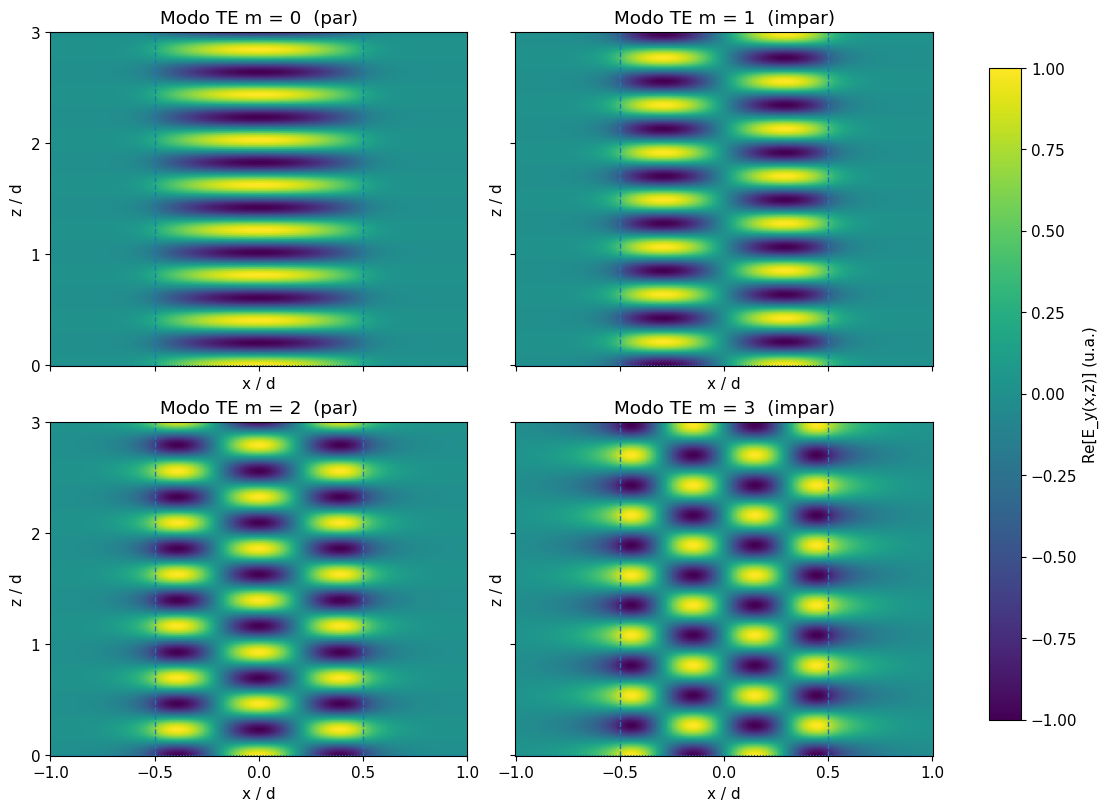

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# Parámetros del slab de Yeh
# ============================
n1 = 1.5          # índice de los claddings
n2 = 2.5          # índice del núcleo
lam = 1.0         # longitud de onda (unidad)
d = lam           # espesor del núcleo
k0 = 2*np.pi/lam  # número de onda en vacío

# Valores de neff = β / k0 (Yeh, pág. 307)
beta_bar = np.array([2.463, 2.348, 2.148, 1.850])   # m = 0,1,2,3
beta = k0 * beta_bar                                # β físico

# Parámetros transversales (Yeh, Ec. 11.1-9)
h = k0 * np.sqrt(n2**2 - beta_bar**2)
q = k0 * np.sqrt(beta_bar**2 - n1**2)

# ============================
# Perfil transversal Em(x)
# ============================
def Em_profile(x, h_m, q_m, d, mode_type):
    x = np.array(x)
    Em = np.zeros_like(x, dtype=float)
    x_abs = np.abs(x)

    inside = x_abs < d/2
    outside = ~inside

    if mode_type == "even":
        B = 1.0
        Em[inside] = B * np.cos(h_m * x[inside])
        Em[outside] = B * np.cos(h_m * d/2) * np.exp(-q_m * (x_abs[outside] - d/2))
    else:  # odd
        A = 1.0
        Em[inside] = A * np.sin(h_m * x[inside])
        Em[outside] = (
            A * np.sign(x[outside])
            * np.sin(h_m * d/2)
            * np.exp(-q_m * (x_abs[outside] - d/2))
        )

    Em /= np.max(np.abs(Em))   # normalización estética
    return Em

# ============================
# Malla (x,z)
# ============================
x_min, x_max = -d, d          # cubrimos claddings y núcleo
z_min, z_max = 0.0, 3*d       # unas cuantas longitudes de guía

Nx, Nz = 500, 500
x = np.linspace(x_min, x_max, Nx)
z = np.linspace(z_min, z_max, Nz)
X, Z = np.meshgrid(x, z)

t0 = 0.0  # tiempo fijo

# ============================
# Cálculo de los 4 modos
# ============================
mode_types = ["even", "odd", "even", "odd"]  # m = 0,1,2,3

# Ajustes de fuente para que se vea más pro
plt.rcParams["font.size"] = 11

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True,
                         constrained_layout=True)
axes = axes.ravel()

# Para usar la misma escala de colores en todos
Ey_values = []

for m in range(4):
    h_m = h[m]
    q_m = q[m]
    beta_m = beta[m]
    mode_type = mode_types[m]

    Em = Em_profile(X, h_m, q_m, d, mode_type)
    Ey_real = Em * np.cos(beta_m * Z)
    Ey_values.append(Ey_real)

Ey_all = np.array(Ey_values)
vmax = np.max(np.abs(Ey_all))
vmin = -vmax

for m in range(4):
    Ey_real = Ey_values[m]

    ax = axes[m]
    im = ax.pcolormesh(X/d, Z/d, Ey_real, shading='auto',
                       vmin=vmin, vmax=vmax)

    tipo = "par" if mode_types[m] == "even" else "impar"
    ax.set_title(f"Modo TE m = {m}  ({tipo})")

    ax.set_xlabel("x / d")
    ax.set_ylabel("z / d")

    # Límites del núcleo: x = ±d/2  →  x/d = ±0.5
    ax.axvline(-0.5, linestyle='--', linewidth=1)
    ax.axvline(+0.5, linestyle='--', linewidth=1)

    # Líneas horizontales para enmarcar la guía
    ax.axhline(0.0, linestyle=':', linewidth=0.8)
    ax.axhline(z_max/d, linestyle=':', linewidth=0.8)

    # Ticks bonitos
    ax.set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0])
    ax.set_yticks([0.0, 1.0, 2.0, 3.0])

# Barra de color común
cbar = fig.colorbar(im, ax=axes, shrink=0.9)
cbar.set_label("Re[E_y(x,z)] (u.a.)")

plt.show()


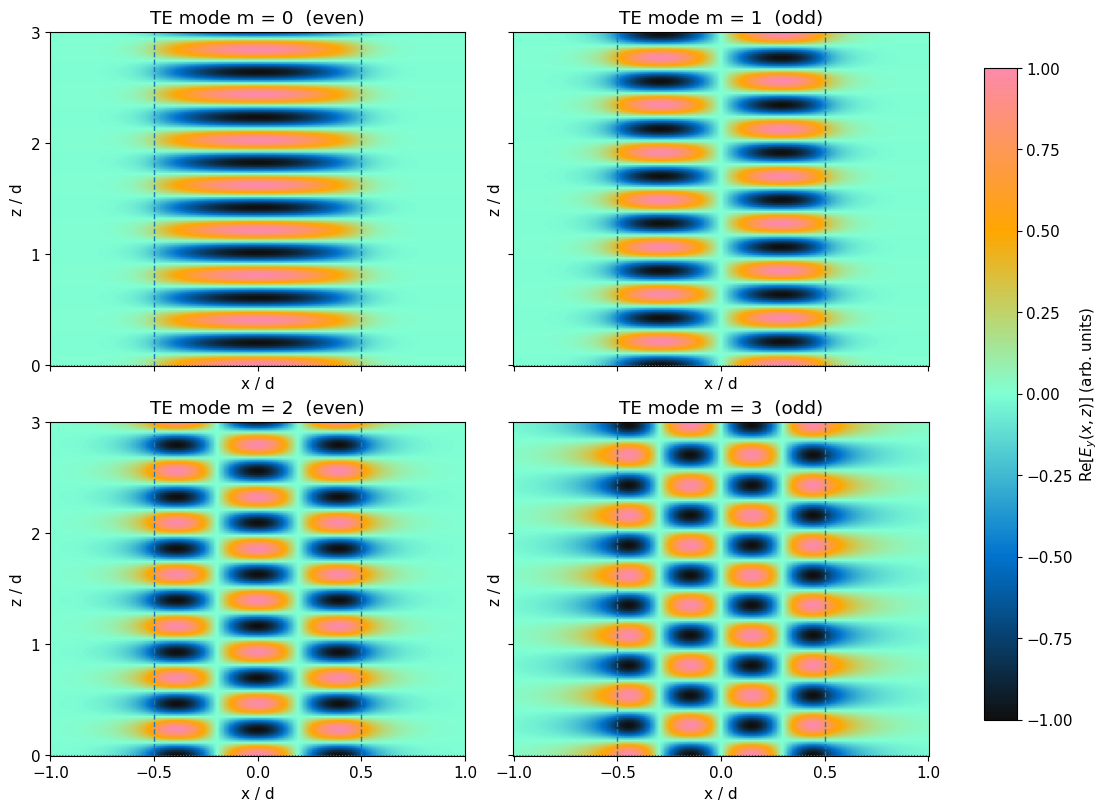

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ============================
# Yeh slab parameters
# ============================
n1 = 1.5          # cladding index
n2 = 2.5          # core index
lam = 1.0         # wavelength (units)
d = lam           # core thickness
k0 = 2 * np.pi / lam  # free-space wavenumber

# Values of neff = β / k0 (Yeh, page 307)
beta_bar = np.array([2.463, 2.348, 2.148, 1.850])   # m = 0,1,2,3
beta = k0 * beta_bar                                # physical β

# Transverse parameters (Yeh, Eq. 11.1-9)
h = k0 * np.sqrt(n2**2 - beta_bar**2)
q = k0 * np.sqrt(beta_bar**2 - n1**2)

# ============================
# Transverse profile Em(x)
# ============================
def Em_profile(x, h_m, q_m, d, mode_type):
    """
    Compute the transverse field profile Em(x) for a given mode.
    mode_type: "even" or "odd".
    """
    x = np.array(x)
    Em = np.zeros_like(x, dtype=float)
    x_abs = np.abs(x)

    inside = x_abs < d / 2
    outside = ~inside

    if mode_type == "even":
        B = 1.0
        Em[inside] = B * np.cos(h_m * x[inside])
        Em[outside] = B * np.cos(h_m * d / 2) * np.exp(-q_m * (x_abs[outside] - d / 2))
    else:  # odd
        A = 1.0
        Em[inside] = A * np.sin(h_m * x[inside])
        Em[outside] = (
            A * np.sign(x[outside])
            * np.sin(h_m * d / 2)
            * np.exp(-q_m * (x_abs[outside] - d / 2))
        )

    # Aesthetic normalization
    Em /= np.max(np.abs(Em))
    return Em

# ============================
# (x,z) grid
# ============================
x_min, x_max = -d, d          # cover claddings + core
z_min, z_max = 0.0, 3 * d     # a few guide lengths

Nx, Nz = 500, 500
x = np.linspace(x_min, x_max, Nx)
z = np.linspace(z_min, z_max, Nz)
X, Z = np.meshgrid(x, z)

t0 = 0.0  # fixed time

# ============================
# Four TE modes
# ============================
mode_types = ["even", "odd", "even", "odd"]  # m = 0,1,2,3

# Font settings for nicer plots
plt.rcParams["font.size"] = 11

fig, axes = plt.subplots(
    2, 2, figsize=(11, 8), sharex=True, sharey=True, constrained_layout=True
)
axes = axes.ravel()

# ============================
# Custom colormap from your palette
# (onyx → trueblue → Aguamarina → orange(webcolor) → ticklemepink)
# ============================
colors = [
    (0.06, 0.06, 0.06),      # onyx
    (0.0, 0.45, 0.81),       # trueblue
    (0.5, 1.0, 0.83),        # Aguamarina
    (1.0, 0.65, 0.0),        # orange(webcolor)
    (0.99, 0.54, 0.67),      # ticklemepink
]
cmap_te = LinearSegmentedColormap.from_list("te_slab_cmap", colors)

# Store all fields to set common color scale
Ey_values = []

for m in range(4):
    h_m = h[m]
    q_m = q[m]
    beta_m = beta[m]
    mode_type = mode_types[m]

    Em = Em_profile(X, h_m, q_m, d, mode_type)
    Ey_real = Em * np.cos(beta_m * Z)   # Re[E_y(x,z,t0)]
    Ey_values.append(Ey_real)

Ey_all = np.array(Ey_values)
vmax = np.max(np.abs(Ey_all))
vmin = -vmax

# ============================
# Plotting
# ============================
for m in range(4):
    Ey_real = Ey_values[m]
    ax = axes[m]

    im = ax.pcolormesh(
        X / d, Z / d, Ey_real, shading="auto",
        vmin=vmin, vmax=vmax, cmap=cmap_te
    )

    mode_label = "even" if mode_types[m] == "even" else "odd"
    ax.set_title(f"TE mode m = {m}  ({mode_label})")

    ax.set_xlabel("x / d")
    ax.set_ylabel("z / d")

    # Core boundaries: x = ±d/2 → x/d = ±0.5
    ax.axvline(-0.5, linestyle="--", linewidth=1)
    ax.axvline(+0.5, linestyle="--", linewidth=1)

    # Horizontal guide lines
    ax.axhline(0.0, linestyle=":", linewidth=0.8)
    ax.axhline(z_max / d, linestyle=":", linewidth=0.8)

    # Nice ticks
    ax.set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0])
    ax.set_yticks([0.0, 1.0, 2.0, 3.0])

# Common colorbar
cbar = fig.colorbar(im, ax=axes, shrink=0.9)
cbar.set_label(r"Re[$E_y(x,z)$] (arb. units)")

plt.show()


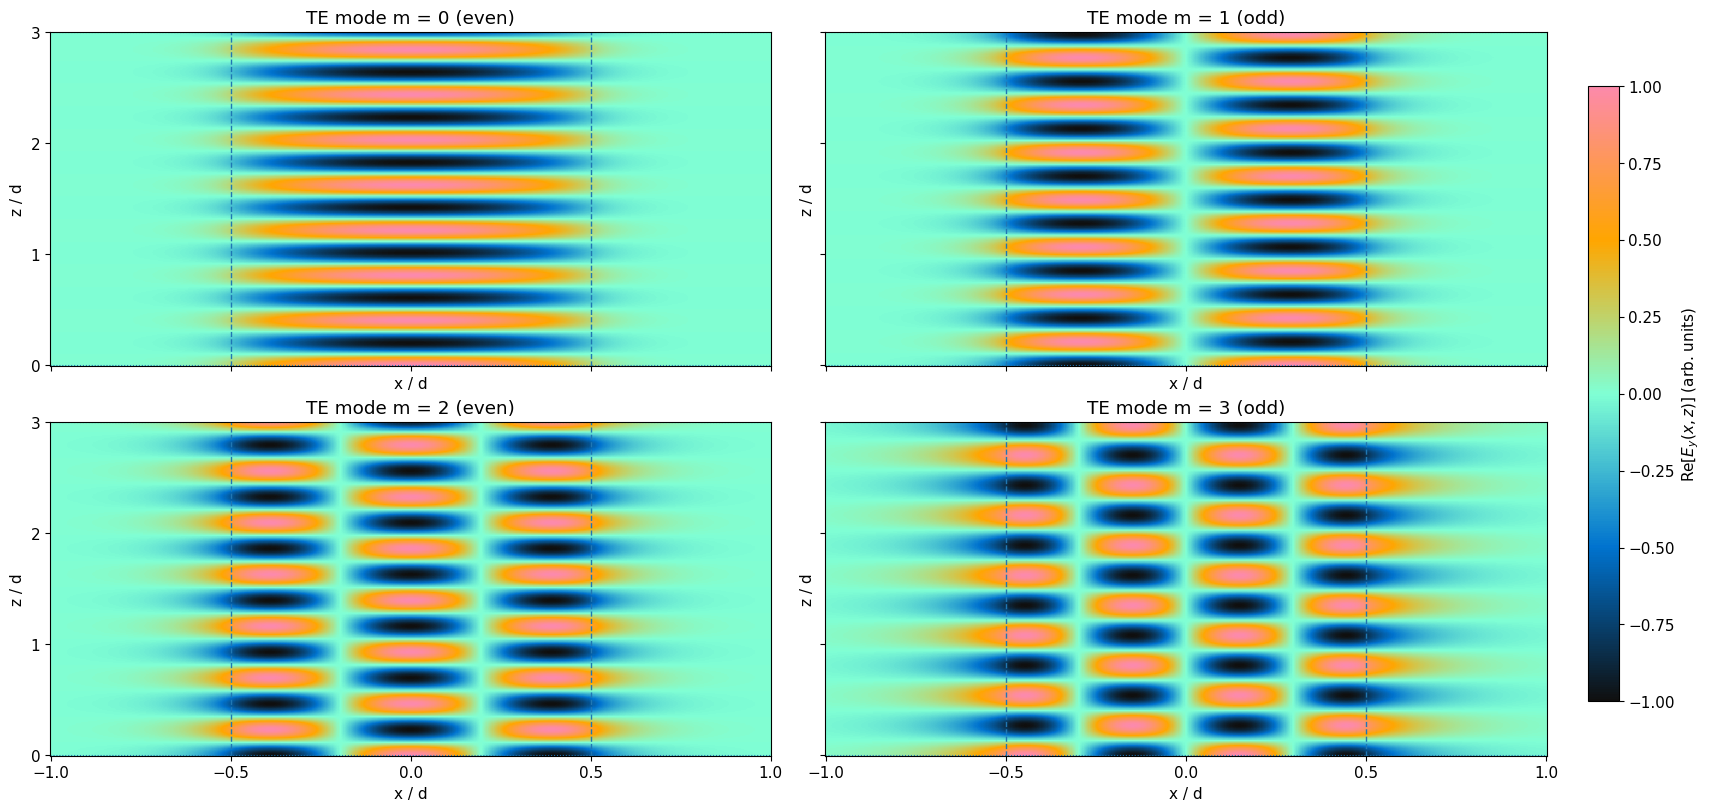

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ============================
# Yeh slab parameters
# ============================
n1 = 1.5          # cladding index
n2 = 2.5          # core index
lam = 1.0         # wavelength (units)
d = lam           # core thickness
k0 = 2 * np.pi / lam  # free-space wavenumber

# Values of neff = β / k0 (Yeh, page 307)
beta_bar = np.array([2.463, 2.348, 2.148, 1.850])   # m = 0,1,2,3
beta = k0 * beta_bar                                # physical β

# Transverse parameters (Yeh, Eq. 11.1-9)
h = k0 * np.sqrt(n2**2 - beta_bar**2)
q = k0 * np.sqrt(beta_bar**2 - n1**2)

# ============================
# Transverse profile Em(x)
# ============================
def Em_profile(x, h_m, q_m, d, mode_type):
    """
    Compute the transverse field profile Em(x) for a given mode.
    mode_type: "even" or "odd"
    """
    x = np.array(x)
    Em = np.zeros_like(x, dtype=float)
    x_abs = np.abs(x)

    inside = x_abs < d / 2
    outside = ~inside

    if mode_type == "even":
        B = 1.0
        Em[inside] = B * np.cos(h_m * x[inside])
        Em[outside] = B * np.cos(h_m * d / 2) * np.exp(-q_m * (x_abs[outside] - d / 2))
    else:  # odd
        A = 1.0
        Em[inside] = A * np.sin(h_m * x[inside])
        Em[outside] = (
            A * np.sign(x[outside])
            * np.sin(h_m * d / 2)
            * np.exp(-q_m * (x_abs[outside] - d / 2))
        )

    # Aesthetic normalization
    Em /= np.max(np.abs(Em))
    return Em

# ============================
# (x,z) grid
# ============================
x_min, x_max = -d, d
z_min, z_max = 0.0, 3 * d

Nx, Nz = 600, 600
x = np.linspace(x_min, x_max, Nx)
z = np.linspace(z_min, z_max, Nz)
X, Z = np.meshgrid(x, z)

# ============================
# Four TE modes
# ============================
mode_types = ["even", "odd", "even", "odd"]

plt.rcParams["font.size"] = 11

# WIDE layout for presentation
fig, axes = plt.subplots(
    2, 2, figsize=(17, 8),
    sharex=True, sharey=True,
    constrained_layout=True
)
axes = axes.ravel()

# ============================
# Custom colormap (your palette)
# ============================
colors = [
    (0.06, 0.06, 0.06),      # onyx
    (0.0, 0.45, 0.81),       # trueblue
    (0.5, 1.0, 0.83),        # Aguamarina
    (1.0, 0.65, 0.0),        # orange(webcolor)
    (0.99, 0.54, 0.67),      # ticklemepink
]
cmap_te = LinearSegmentedColormap.from_list("te_slab_cmap", colors)

# ============================
# Compute all modes first (for common scale)
# ============================
Ey_values = []
for m in range(4):
    Em = Em_profile(X, h[m], q[m], d, mode_types[m])
    Ey_real = Em * np.cos(beta[m] * Z)
    Ey_values.append(Ey_real)

Ey_all = np.array(Ey_values)
vmax = np.max(np.abs(Ey_all))
vmin = -vmax

# ============================
# Plotting
# ============================
for m in range(4):
    Ey_real = Ey_values[m]
    ax = axes[m]

    im = ax.pcolormesh(
        X / d, Z / d, Ey_real,
        shading="auto",
        vmin=vmin, vmax=vmax,
        cmap=cmap_te
    )

    mode_label = "even" if mode_types[m] == "even" else "odd"
    ax.set_title(f"TE mode m = {m} ({mode_label})")

    ax.set_xlabel("x / d")
    ax.set_ylabel("z / d")

    # Core boundaries
    ax.axvline(-0.5, linestyle="--", linewidth=1)
    ax.axvline(+0.5, linestyle="--", linewidth=1)

    # Guide lines in z
    ax.axhline(0.0, linestyle=":", linewidth=0.8)
    ax.axhline(z_max / d, linestyle=":", linewidth=0.8)

    # Ticks
    ax.set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0])
    ax.set_yticks([0.0, 1.0, 2.0, 3.0])

    # Allow wide stretching
    ax.set_aspect("auto")

# ============================
# Common colorbar
# ============================
cbar = fig.colorbar(
    im, ax=axes,
    shrink=0.85,
    fraction=0.035,
    pad=0.02
)
cbar.set_label(r"Re[$E_y(x,z)$] (arb. units)")

# ============================
# Save HIGH-RESOLUTION PNG
# ============================
plt.savefig(
    "TE_slab_modes_Yeh_high_resolution.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()
